# **Feature Detection & Matching**

## **Objectives:**
1. Detect keypoints & descriptors — SIFT, ORB, AKAZE
2. Match descriptors — Brute-Force matching and Lowe's ratio test
3. Filter matches with RANSAC and estimate a homography
4. Localize a known object inside a cluttered scene

> **Assets.** `assets/images/box.png` / `box_in_scene.png` are OpenCV's own official sample images ([opencv/opencv, Apache 2.0](https://github.com/opencv/opencv/tree/4.x/samples/data)) — the classic pair used for feature-matching tutorials: a clean product-box photo, and the same box lying rotated, scaled, and partly occluded in a cluttered scene.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

## **What's a keypoint, intuitively?**

A *keypoint* is a small, distinctive spot in an image — a corner, a blob, a sharp change in texture — that you could point to again in a *different* photo of the same object and have a good chance of finding the same spot. Flat regions and straight edges make bad keypoints (too many candidate matches — the *aperture problem* from notebook 25 shows up here too); corners and high-frequency texture make good ones.

A *descriptor* is a numeric fingerprint of the neighborhood around a keypoint — a vector built so that the *same* physical spot, seen from a different angle, scale, or lighting, produces a *similar* vector. Matching two images then becomes: find keypoints in both, describe each one, and pair up descriptors that are close together in that vector space.

- **SIFT** (`cv2.SIFT_create`) — builds descriptors from local gradient histograms across a scale-space pyramid, so it's genuinely scale- and rotation-invariant. Slower, but the accuracy baseline everything else is judged against.
- **ORB** (`cv2.ORB_create`) — a fast, free (patent-free, unlike the older SIFT) binary descriptor built from pixel-intensity comparisons (BRIEF) on top of FAST corners. Matched with Hamming distance instead of Euclidean — much cheaper per comparison.
- **AKAZE** (`cv2.AKAZE_create`) — builds its scale-space with nonlinear diffusion instead of SIFT's Gaussian blurring, which keeps edges sharper while still smoothing out noise; a good middle ground on speed vs. accuracy.

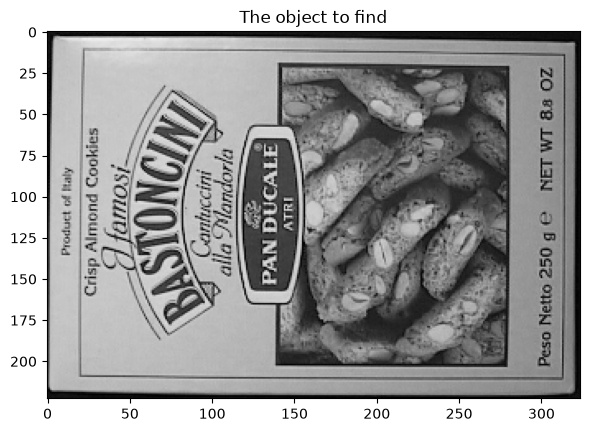

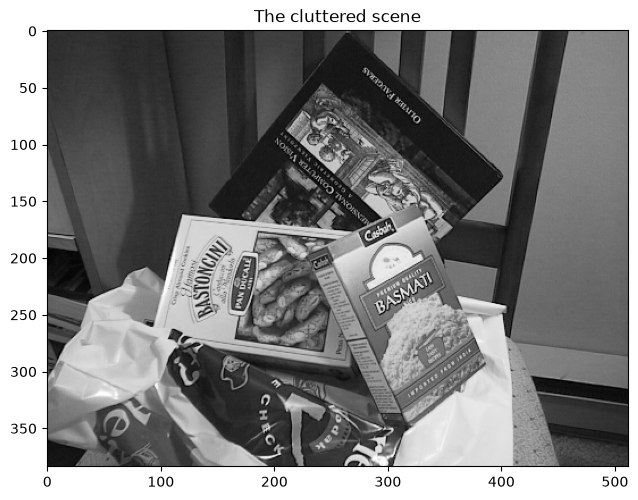

In [2]:
box = cv2.imread('assets/images/box.png')
scene = cv2.imread('assets/images/box_in_scene.png')
box_gray = cv2.cvtColor(box, cv2.COLOR_BGR2GRAY)
scene_gray = cv2.cvtColor(scene, cv2.COLOR_BGR2GRAY)

imshow('The object to find', box)
imshow('The cluttered scene', scene)

## **Detecting & drawing keypoints**

`detector.detectAndCompute(image, mask)` returns a list of `cv2.KeyPoint` objects (position, size, orientation) plus a matrix of descriptors, one row per keypoint. `cv2.drawKeypoints(..., flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)` draws each keypoint's actual scale and orientation as a sized, rotated circle — worth comparing against the plain-dot default to see *why* scale/orientation invariance matters.

SIFT keypoints — box: 604, scene: 969


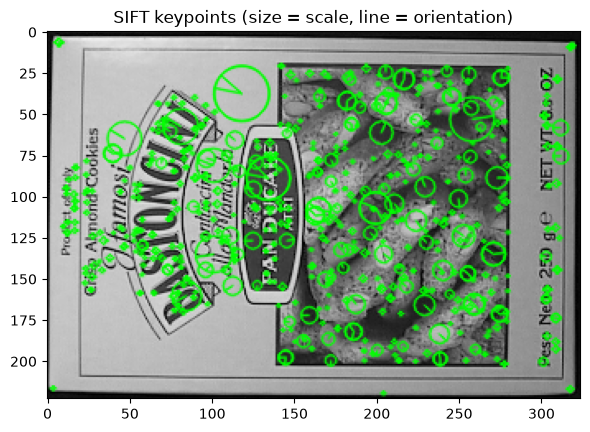

In [3]:
sift = cv2.SIFT_create()
kp_box, des_box = sift.detectAndCompute(box_gray, None)
kp_scene, des_scene = sift.detectAndCompute(scene_gray, None)
print(f'SIFT keypoints — box: {len(kp_box)}, scene: {len(kp_scene)}')

box_kp_vis = cv2.drawKeypoints(
    box, kp_box, None, (0, 255, 0),
    cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
)
imshow('SIFT keypoints (size = scale, line = orientation)', box_kp_vis)

## **Matching descriptors: Brute-Force + Lowe's ratio test**

`cv2.BFMatcher` compares every descriptor in image A against every descriptor in image B and keeps the closest ones. `knnMatch(des1, des2, k=2)` asks for the *two* closest matches per query descriptor, not just the best one — and that second-best match is the whole trick:

**Lowe's ratio test**: a match is only trustworthy if the best candidate is *clearly* better than the second-best one. If `distance(best) < 0.75 * distance(second_best)`, keep it; otherwise the descriptor is ambiguous (it matched two different spots almost equally well — often a repeated texture or noise) and gets thrown away. This one ratio check is what turns a noisy "every keypoint kind of matches something" result into a small set of confident correspondences.

604 candidate matches -> 80 after Lowe's ratio test


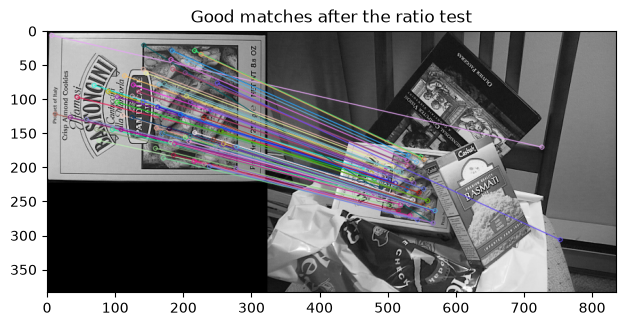

In [4]:
bf = cv2.BFMatcher()
knn_matches = bf.knnMatch(des_box, des_scene, k=2)

good_matches = [m for m, n in knn_matches if m.distance < 0.75 * n.distance]
print(f'{len(knn_matches)} candidate matches -> {len(good_matches)} after Lowe\'s ratio test')

match_vis = cv2.drawMatches(
    box, kp_box, scene, kp_scene, good_matches, None,
    flags=cv2.DRAW_MATCHES_FLAGS_NOT_DRAW_SINGLE_POINTS,
)
imshow('Good matches after the ratio test', match_vis, size=16)

## **RANSAC & homography: from matches to a location**

Even after the ratio test, a few matches are still wrong (a corner on the box that coincidentally resembles a corner somewhere else in the scene). **RANSAC** (Random Sample Consensus) handles that robustly: repeatedly pick a small random subset of matches, fit a homography to just those, and check how many *other* matches agree with it (the *inliers*). Keep the homography with the most agreement, then refit it using every inlier. A handful of wrong matches (*outliers*) simply never get picked consistently enough to win.

A **homography** is the 3×3 matrix that maps a flat surface seen from one viewpoint onto the same surface seen from another — exactly the perspective warp from notebook 18, but now *estimated from matched points* instead of four manually-clicked corners. `cv2.perspectiveTransform` projects the box's own corner coordinates through that matrix, drawing the box's outline directly onto the scene — the object has been *localized*, not just matched.

RANSAC: 75/80 matches are inliers


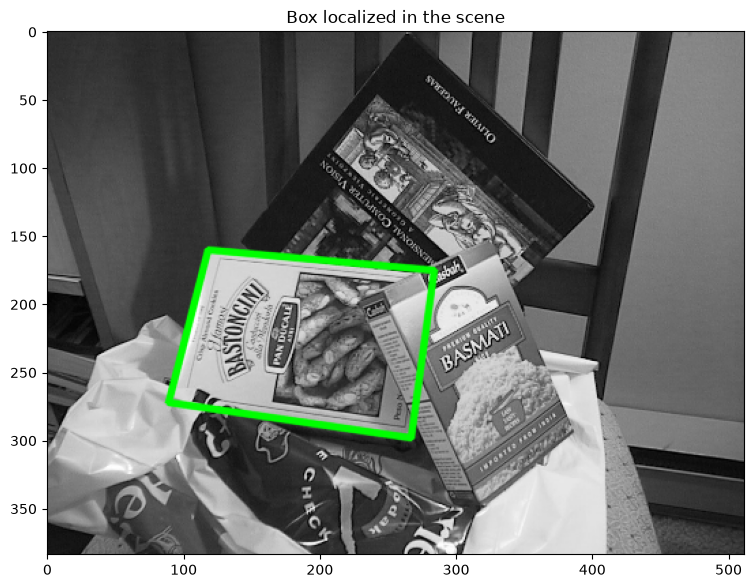

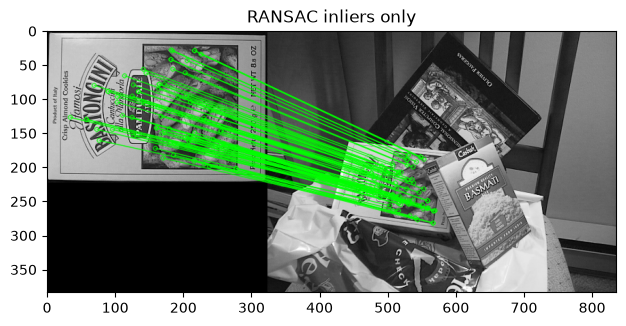

In [5]:
src_pts = np.float32([kp_box[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp_scene[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

H, inlier_mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
n_inliers = int(inlier_mask.sum())
print(f'RANSAC: {n_inliers}/{len(good_matches)} matches are inliers')

h, w = box_gray.shape
box_corners = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)
scene_corners = cv2.perspectiveTransform(box_corners, H)

located = scene.copy()
cv2.polylines(located, [np.int32(scene_corners)], True, (0, 255, 0), 4, cv2.LINE_AA)
imshow('Box localized in the scene', located, size=12)

inlier_matches = [m for m, keep in zip(good_matches, inlier_mask.ravel()) if keep]
inlier_vis = cv2.drawMatches(
    box, kp_box, scene, kp_scene, inlier_matches, None,
    matchColor=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_NOT_DRAW_SINGLE_POINTS,
)
imshow('RANSAC inliers only', inlier_vis, size=16)

## **ORB & AKAZE — the fast, patent-free alternatives**

SIFT was patented until 2020 and is still the accuracy reference, but ORB and AKAZE run considerably faster and are what most real-time applications (SLAM, AR tracking, notebook 24-26's tracking problem if you swapped in feature tracking instead of color/motion) actually use. Same pipeline, different detector — and ORB's binary descriptors need `cv2.NORM_HAMMING`, not the default L2 norm BFMatcher uses for SIFT's float descriptors.

ORB: 865 keypoints, 42 good matches after the ratio test


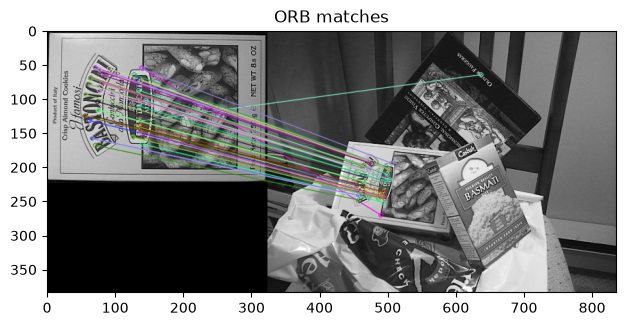

AKAZE: 383 keypoints, 24 good matches after the ratio test


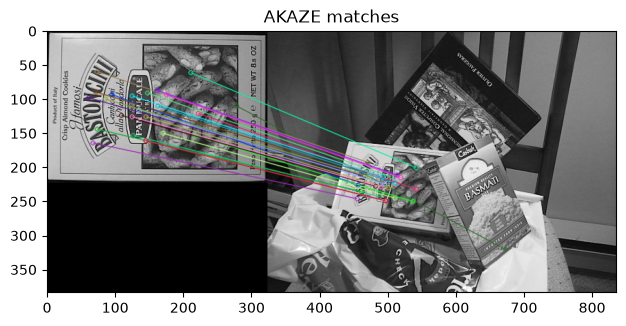

In [6]:
orb = cv2.ORB_create(nfeatures=1000)
akaze = cv2.AKAZE_create()

for name, detector, norm in [('ORB', orb, cv2.NORM_HAMMING), ('AKAZE', akaze, cv2.NORM_HAMMING)]:
    kp1, d1 = detector.detectAndCompute(box_gray, None)
    kp2, d2 = detector.detectAndCompute(scene_gray, None)
    bf_bin = cv2.BFMatcher(norm)
    knn = bf_bin.knnMatch(d1, d2, k=2)
    good = [m for pair in knn if len(pair) == 2 for m, n in [pair] if m.distance < 0.75 * n.distance]
    print(f'{name}: {len(kp1)} keypoints, {len(good)} good matches after the ratio test')
    vis = cv2.drawMatches(box, kp1, scene, kp2, good, None,
                            flags=cv2.DRAW_MATCHES_FLAGS_NOT_DRAW_SINGLE_POINTS)
    imshow(f'{name} matches', vis, size=16)

### A couple of directions to take this

- Swap `cv2.RANSAC` for `cv2.USAC_MAGSAC` in `findHomography` — a more modern robust estimator — and compare the inlier count and the drawn outline's stability.
- Time SIFT vs. ORB vs. AKAZE with `%%timeit` on `detectAndCompute` alone — the speed gap is the whole reason ORB exists.
- This notebook localizes one known object; notebook 28 reuses the exact same detect → match → RANSAC-homography pipeline to stitch overlapping *photos* instead of finding an *object* — same math, different goal.